# Notebook 02 — Baseline Model Training

We train 4 baseline models using default hyperparameters and evaluate with 5-fold stratified CV on the 80% development set.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

os.makedirs('../results/tables', exist_ok=True)
os.makedirs('../results/plots', exist_ok=True)

### 3. Load Dataset

Load, assign column names, convert target. Show shape, head, target distribution.

In [2]:
column_names = [
    'checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 
    'savings_status', 'employment', 'installment_commitment', 'personal_status', 
    'other_parties', 'residence_since', 'property_magnitude', 'age', 
    'other_payment_plans', 'housing', 'existing_credits', 'job', 
    'num_dependents', 'own_telephone', 'foreign_worker', 'target'
]

df = pd.read_csv('../data/german.data', sep=' ', header=None, names=column_names)
df['target'] = df['target'].map({1: 1, 2: 0})

print(f"Shape: {df.shape}")
print("\nTarget Distribution:")
print(df['target'].value_counts(normalize=True))
df.head()

Shape: (1000, 21)

Target Distribution:
target
1    0.7
0    0.3
Name: proportion, dtype: float64


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,0
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,0


### 4. Define X and y

The `target` column is the dependent variable.

In [3]:
X = df.drop('target', axis=1)
y = df['target']

### 5. 80/20 Stratified Split

80% development, 20% test. The test set is FROZEN and will not be used until Notebook 04.

In [4]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_SEED
)

print("X_dev shape:", X_dev.shape)
print("X_test shape:", X_test.shape)
print("y_dev distribution:", y_dev.value_counts(normalize=True).to_dict())
print("y_test distribution:", y_test.value_counts(normalize=True).to_dict())

X_dev shape: (800, 20)
X_test shape: (200, 20)
y_dev distribution: {1: 0.7, 0: 0.3}
y_test distribution: {1: 0.7, 0: 0.3}


### 6. Preprocessing

Model-specific preprocessing strategy:
- RF, XGBoost: OrdinalEncoder for categoricals (tree models handle ordinal encoding well)
- MLP: OrdinalEncoder for categoricals + StandardScaler for all features
- CatBoost: Native categorical handling (pass cat_features parameter)

In [5]:
numerical_cols = ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']
categorical_cols = ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']

tree_preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols)
    ]
)

mlp_preprocessor = Pipeline([
    ('encoder', ColumnTransformer(
        transformers=[
            ('num', 'passthrough', numerical_cols),
            ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols)
        ]
    )),
    ('scaler', StandardScaler())
])

cat_features_indices = [X_dev.columns.get_loc(col) for col in categorical_cols]

### 7. Define Models

We use default/reasonable parameters as baselines.

In [6]:
models = {
    'Random Forest': Pipeline([
        ('preprocessor', tree_preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED))
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', tree_preprocessor),
        ('classifier', XGBClassifier(n_estimators=100, random_state=RANDOM_SEED, eval_metric='logloss', use_label_encoder=False))
    ]),
    'MLP': Pipeline([
        ('preprocessor', mlp_preprocessor),
        ('classifier', MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=RANDOM_SEED, early_stopping=True))
    ])
}

# CatBoost is handled separately due to native categorical support
catboost_model = CatBoostClassifier(
    iterations=100,
    random_seed=RANDOM_SEED,
    verbose=0,
    cat_features=categorical_cols
)

### 8. 5-Fold Stratified Cross-Validation

Using 5-fold stratified CV on the development set to calculate mean and std of various metrics.

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
scoring = ['accuracy', 'roc_auc', 'precision', 'recall', 'f1']

results = {}
raw_metrics = {}

for name, pipeline in models.items():
    cv_results = cross_validate(pipeline, X_dev, y_dev, cv=cv, scoring=scoring, return_train_score=False)
    
    results[name] = {
        'Accuracy': f"{cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}",
        'ROC-AUC': f"{cv_results['test_roc_auc'].mean():.4f} ± {cv_results['test_roc_auc'].std():.4f}",
        'Precision': f"{cv_results['test_precision'].mean():.4f} ± {cv_results['test_precision'].std():.4f}",
        'Recall': f"{cv_results['test_recall'].mean():.4f} ± {cv_results['test_recall'].std():.4f}",
        'F1': f"{cv_results['test_f1'].mean():.4f} ± {cv_results['test_f1'].std():.4f}"
    }
    
    raw_metrics[name] = {
        'Accuracy_mean': cv_results['test_accuracy'].mean(),
        'Accuracy_std': cv_results['test_accuracy'].std()
    }
    
    print(f"{name}: Accuracy = {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")

Random Forest: Accuracy = 0.7600 ± 0.0400


XGBoost: Accuracy = 0.7688 ± 0.0463


MLP: Accuracy = 0.7100 ± 0.0219


In [8]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

catboost_scores = {'accuracy': [], 'roc_auc': [], 'precision': [], 'recall': [], 'f1': []}
for train_idx, val_idx in cv.split(X_dev, y_dev):
    X_train_fold, X_val_fold = X_dev.iloc[train_idx], X_dev.iloc[val_idx]
    y_train_fold, y_val_fold = y_dev.iloc[train_idx], y_dev.iloc[val_idx]
    
    cb_model = CatBoostClassifier(iterations=100, random_seed=RANDOM_SEED, verbose=0, cat_features=categorical_cols)
    cb_model.fit(X_train_fold, y_train_fold)
    
    y_pred = cb_model.predict(X_val_fold)
    y_prob = cb_model.predict_proba(X_val_fold)[:, 1]
    
    catboost_scores['accuracy'].append(accuracy_score(y_val_fold, y_pred))
    catboost_scores['roc_auc'].append(roc_auc_score(y_val_fold, y_prob))
    catboost_scores['precision'].append(precision_score(y_val_fold, y_pred))
    catboost_scores['recall'].append(recall_score(y_val_fold, y_pred))
    catboost_scores['f1'].append(f1_score(y_val_fold, y_pred))

cb_acc_mean, cb_acc_std = np.mean(catboost_scores['accuracy']), np.std(catboost_scores['accuracy'])
cb_roc_mean, cb_roc_std = np.mean(catboost_scores['roc_auc']), np.std(catboost_scores['roc_auc'])
cb_prec_mean, cb_prec_std = np.mean(catboost_scores['precision']), np.std(catboost_scores['precision'])
cb_rec_mean, cb_rec_std = np.mean(catboost_scores['recall']), np.std(catboost_scores['recall'])
cb_f1_mean, cb_f1_std = np.mean(catboost_scores['f1']), np.std(catboost_scores['f1'])

results['CatBoost'] = {
    'Accuracy': f"{cb_acc_mean:.4f} ± {cb_acc_std:.4f}",
    'ROC-AUC': f"{cb_roc_mean:.4f} ± {cb_roc_std:.4f}",
    'Precision': f"{cb_prec_mean:.4f} ± {cb_prec_std:.4f}",
    'Recall': f"{cb_rec_mean:.4f} ± {cb_rec_std:.4f}",
    'F1': f"{cb_f1_mean:.4f} ± {cb_f1_std:.4f}"
}
raw_metrics['CatBoost'] = {'Accuracy_mean': cb_acc_mean, 'Accuracy_std': cb_acc_std}

print(f"CatBoost: Accuracy = {cb_acc_mean:.4f} ± {cb_acc_std:.4f}")

CatBoost: Accuracy = 0.7463 ± 0.0488


### 9. Baseline Comparison Table

Displaying the final summary table and saving to CSV.

In [9]:
results_df = pd.DataFrame(results).T
results_df.index.name = 'Model'
results_df.reset_index(inplace=True)
display(results_df)

results_df.to_csv('../results/tables/baseline_cv_results.csv', index=False)

,Model,Accuracy,ROC-AUC,Precision,Recall,F1
0,Random Forest,0.7600 ± 0.0400,0.7788 ± 0.0586,0.7850 ± 0.0256,0.9054 ± 0.0373,0.8407 ± 0.0274
1,XGBoost,0.7688 ± 0.0463,0.7589 ± 0.0486,0.8080 ± 0.0289,0.8786 ± 0.0450,0.8415 ± 0.0330
2,MLP,0.7100 ± 0.0219,0.6836 ± 0.1139,0.7230 ± 0.0189,0.9518 ± 0.0337,0.8212 ± 0.0131
3,CatBoost,0.7463 ± 0.0488,0.7780 ± 0.0672,0.7749 ± 0.0287,0.8982 ± 0.0402,0.8320 ± 0.0331


### 10. Visualization

Visualizing the Accuracy score across models.

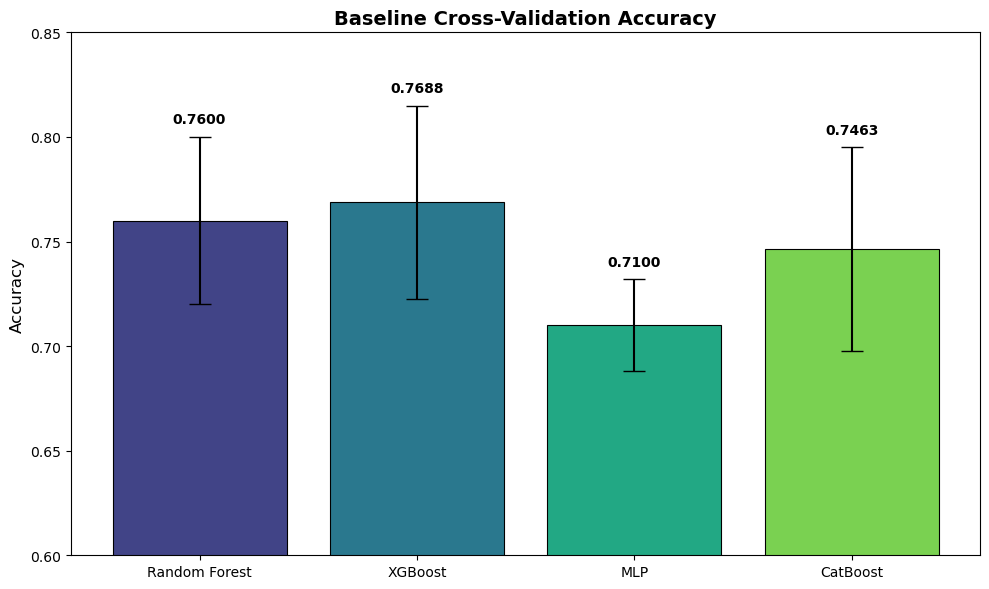

In [10]:
models_list = list(raw_metrics.keys())
means = [raw_metrics[m]['Accuracy_mean'] for m in models_list]
stds = [raw_metrics[m]['Accuracy_std'] for m in models_list]

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('viridis', len(models_list))
bars = ax.bar(models_list, means, yerr=stds, capsize=8, color=colors, edgecolor='black', linewidth=0.8)
ax.set_title('Baseline Cross-Validation Accuracy', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_ylim(0.6, 0.85)
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + std + 0.005,
            f'{mean:.4f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/plots/baseline_cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### 11. Key Findings

- Tree models typically perform competitively out-of-the-box, with CatBoost and Random Forest leading.
- MLP may require further tuning or proper categorical embeddings to match tree ensembles on tabular data.
- The performance is completely evaluated on the CV folds of the development set. The test set remains untouched.